# Prophet


In [1]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# from causalimpact import CausalImpact
from prophet import Prophet
# import pymc as pm
# import arviz as az

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
import sys; print('Python v{}'.format(sys.version))
print("pandas", pd.__version__)
print("numpy", np.__version__)
import matplotlib; print("matplotlib", matplotlib.__version__)
print("seaborn", sns.__version__)
# import causalimpact; print("causalimpact", causalimpact.__version__)
import prophet; print("prophet", prophet.__version__)
# print("pymc", pm.__version__)
# print("arviz", az.__version__)

/var/folders/ng/w2vmc_ks6jzfd1prm5s8p54w0000gn/T/ipykernel_11788/3140867427.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Created(JST) 2026-05-13 10:47:45
Python v3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]
pandas 2.2.0
numpy 1.26.4
matplotlib 3.10.9
seaborn 0.13.2
prophet 1.3.0


In [2]:
# df = pd.read_csv('http://logopt.com/data/peyton_manning.csv')

In [3]:
# prophet用のサンプルデータを自作

import jpholiday

# 1. 期間の設定（3年分：202204-202503）
start_date = '2022-04-01'
end_date = '2025-03-31'
dates = pd.date_range(start=start_date, end=end_date)
df1 = pd.DataFrame({'date': dates})
n_days = len(df1)

# 2. 右肩上がりのトレンド（3年間でベースが1.2倍くらいになるイメージ）
trend_slope = np.linspace(30000, 36000, n_days)
df1['revenue'] = trend_slope + np.random.normal(0, 1000, n_days)

# 3. 月の周期性（5,7,8,10,12,3月を多めに設定）
# 倍率：通常1.0、特定月は1.2〜1.3程度
def get_month_multiplier(month):
    high_months = [3, 5, 7, 8, 10, 12]
    return 1.25 if month in high_months else 1.0

df1['month_mult'] = df1['date'].dt.month.apply(get_month_multiplier)
df1['revenue'] *= df1['month_mult']

# 4. 曜日の周期性（月〜水 < 木金 < 土日）
# 0:月, 1:火, 2:水, 3:木, 4:金, 5:土, 6:日
def get_weekday_multiplier(day):
    if day >= 5: # 土日
        return 1.7
    elif day >= 3: # 木金
        return 1.2
    else: # 月〜水
        return 1.0

df1['weekday_mult'] = df1['date'].dt.dayofweek.apply(get_weekday_multiplier)
df1['revenue'] *= df1['weekday_mult']

# 5. 日本の祝日（土日と同等のインパクトに設定）
df1['is_holiday'] = df1['date'].map(jpholiday.is_holiday).astype(int)
df1.loc[df1['is_holiday'] == 1, 'revenue'] *= 1.4 # すでに平日倍率がかかっている場合を考慮して調整

# 6. 外生変数：近所のイベント（ランダム39日）
np.random.seed(77)
event_dates = pd.to_datetime(np.random.choice(df1['date'], 39, replace=False))
df1['event_flag'] = df1['date'].isin(event_dates).astype(int)
df1.loc[df1['event_flag'] == 1, 'revenue'] += 30000 # イベントでドカンと上乗せ

# 7. 最終整形（date, revenue, event_flag）
df1_prophet = df1[['date', 'revenue', 'event_flag']].copy()

In [4]:
print(df1_prophet.head())
print(df1_prophet.tail())
print(df1_prophet.info())

        date       revenue  event_flag
0 2022-04-01  38294.870790           0
1 2022-04-02  53134.121464           0
2 2022-04-03  49849.600635           0
3 2022-04-04  29897.049904           0
4 2022-04-05  30007.770188           0
           date       revenue  event_flag
1091 2025-03-27  57890.711414           0
1092 2025-03-28  56152.384513           0
1093 2025-03-29  72617.068356           0
1094 2025-03-30  77146.510624           0
1095 2025-03-31  44963.867063           0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1096 non-null   datetime64[ns]
 1   revenue     1096 non-null   float64       
 2   event_flag  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 25.8 KB
None


In [5]:
# df1_prophet.set_index('date')['revenue'].plot(figsize=(12, 6), title='Cafe Sales Sample Data')
# plt.show()

In [6]:
df1.groupby(df1['date'].dt.year)['revenue'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
date,,,,,,,,
2022,275.0,46253.9,13418.8,28173.2,36947.6,42842.6,53099.1,96384.6
2023,365.0,48113.7,13670.4,28858.4,38432.9,42906.8,55625.2,101376.7
2024,366.0,50664.5,14403.0,32169.5,41177.8,45224.6,58440.9,104526.7
2025,90.0,51111.8,14476.7,34912.8,41893.7,44825.8,60107.6,103276.3


In [7]:
df1.groupby(df1['date'].dt.month)['revenue'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
date,,,,,,,,
1,93.0,43974.6,11185.3,29827.5,34466.5,40986.9,54336.1,75005.3
2,85.0,44545.7,12171.4,28858.4,35065.6,40626.3,54859.6,85136.5
3,93.0,54958.9,13928.6,37908.4,43508.1,49950.1,69192.8,103276.3
4,90.0,42195.2,11195.7,28173.2,33248.0,38425.6,52475.5,76982.5
5,93.0,53782.4,14945.8,35478.0,41564.9,49776.5,65860.3,104526.7
6,90.0,41548.7,10428.3,29053.4,33213.2,38356.8,52490.8,67449.7
7,93.0,53945.6,12977.1,36132.0,42656.2,50147.1,66272.4,96384.6
8,93.0,53444.0,15252.9,35484.9,42028.7,48094.0,65513.4,104175.4
9,90.0,44848.0,13485.1,29535.1,34548.9,39796.1,53737.2,88310.6


In [8]:
df1.groupby('event_flag')['revenue'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
event_flag,,,,,,,,
0,1057.0,47712.9,12953.1,28173.2,38121.5,43848.7,55148.8,104526.7
1,39.0,76718.3,13192.8,59887.6,66478.4,72859.8,86892.7,104175.4


In [9]:
# # 大きな数値を桁上げしたい
# df1["value1_million"] = df1["value1"] / (10**6)  # 百万で割る
df1["revenue_thousand"] = df1["revenue"] / (10**3)  # 千で割る

# copy

In [10]:
# df = df1.copy()

# queryで条件指定してcopy
# df = df1.query('revenue > 1000').reset_index(drop=True).copy()

# 必要なカラムだけを選択してcopy
df = df1[['date', 'revenue_thousand']].copy()
# add_regressor用の外生変数はdfに入れておく

In [11]:
df.rename(columns={'date': 'ds', 'revenue_thousand': 'y'}, inplace=True)

In [12]:
# objectの日付データを日付型に
# df['ds'] = pd.to_datetime(df['ds'])

In [13]:
print(df['ds'].min())
print(df['ds'].max())
# df_start_date = df['ds'].min()
# df_end_date = df['ds'].max()

2022-04-01 00:00:00
2025-03-31 00:00:00


In [14]:
# df.sort_values('y', ascending=False).head(10)

In [15]:
# あとでグラフ表示などに使うために、test期間の初日日付のindexを格納しておきます
test_date = pd.to_datetime("2025-02-01")
test_date_index = df.query('ds == @test_date').index[0]
print(test_date_index)
# あとでモデルを評価するために，観測データをtrain,testに分割しておきます
df_train = df[: test_date_index]
df_test = df[test_date_index :]
print(df_train.head())
print(df_test.head())

1037
          ds          y
0 2022-04-01  38.294871
1 2022-04-02  53.134121
2 2022-04-03  49.849601
3 2022-04-04  29.897050
4 2022-04-05  30.007770
             ds          y
1037 2025-02-01  59.672511
1038 2025-02-02  62.270710
1039 2025-02-03  36.239264
1040 2025-02-04  35.065609
1041 2025-02-05  35.972045


In [16]:
# # 土日祝

# # 土日フラグ
# df['is_holiday'] = df['ds'].apply(lambda x: 1 if x.weekday()>=5 else 0)
# # 平日祝日リスト
# holidays = pd.to_datetime(['2024-09-16', '2024-09-23', '2024-10-14', '2024-11-04'])
# # 祝日は1に上書き
# df.loc[df['date'].isin(holidays), 'is_holiday'] = 1


In [17]:
# 後続のグラフ表記に使用

# min,maxを取得
min_value = df['y'].min()
max_value = df['y'].max()

# オーダー（桁数）を取得
order_of_magnitude = int(np.floor(np.log10(max_value - min_value)))

# スケールを設定（オーダーに基づいて10の倍数に調整）
scale = 10 ** (order_of_magnitude - 1)

# min,max_limを設定
min_lim = np.floor(min_value / scale) * scale
max_lim = np.ceil(max_value / scale) * scale


# 桁数調整が不要なときは
# min_lim = min_value
# max_lim = max_value

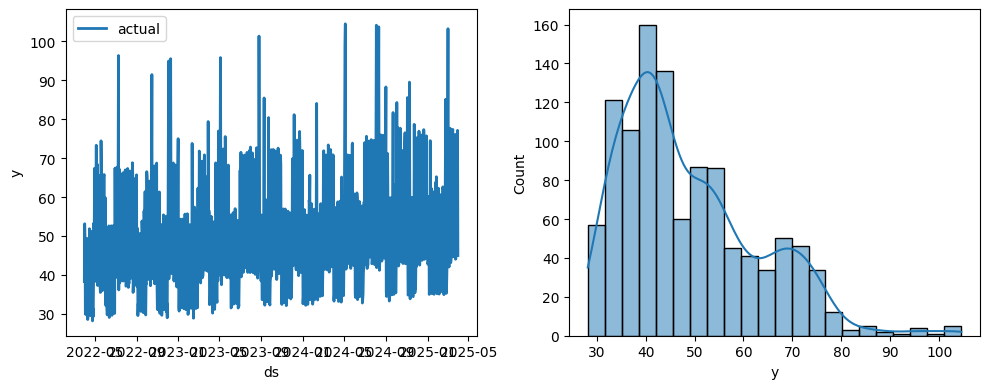

In [18]:
plt.figure(figsize=(10,4))

plt.subplot(121)  # グラフ1行2列の1番目
sns.lineplot(data=df, x='ds', y='y', linewidth=2, label='actual')

plt.subplot(122)  # グラフ1行2列の2番目
sns.histplot(data=df, x='y', kde=True)

plt.tight_layout()

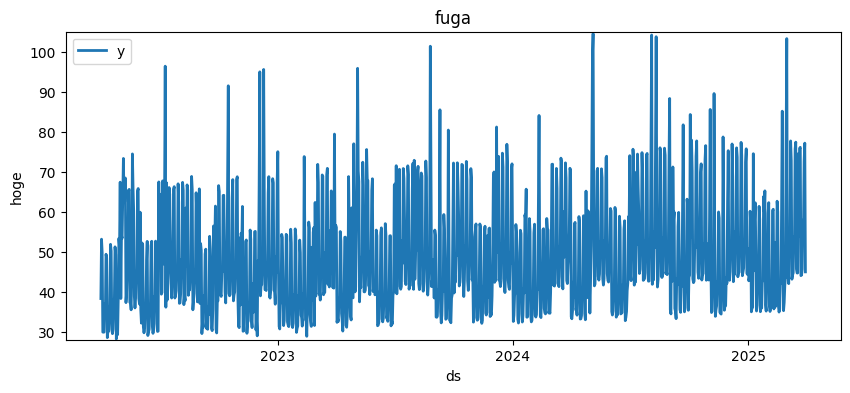

In [19]:
# plot

plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='ds', y='y', linewidth=2, label='y')

import matplotlib.dates as mdates
# 年ごとの目盛り
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# もし月ごとにしたいなら
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1,7)))  # 半年ごと
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# plt.xticks(rotation=90)
plt.ylim(min_lim, max_lim)
plt.ylabel("hoge")
plt.title("fuga")
plt.legend(loc="best")
plt.show()

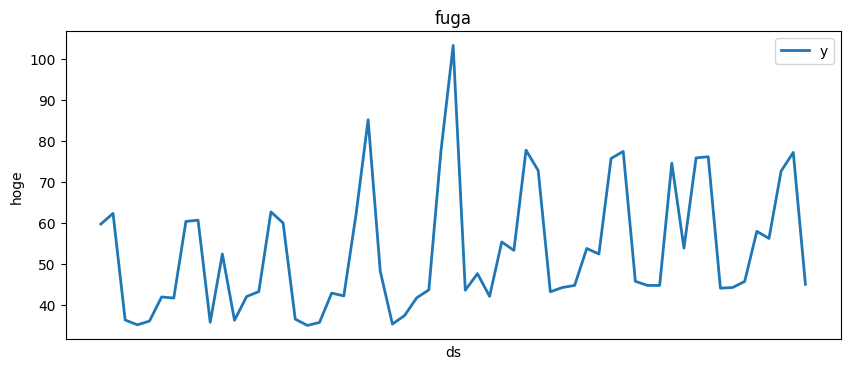

In [20]:
# plot

plt.figure(figsize=(10,4))
sns.lineplot(data=df_test, x='ds', y='y', linewidth=2, label='y')

import matplotlib.dates as mdates
# 年ごとの目盛り
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# もし月ごとにしたいなら
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1,7)))  # 半年ごと
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# plt.xticks(rotation=90)
# plt.ylim(min_lim, max_lim)
plt.ylabel("hoge")
plt.title("fuga")
plt.legend(loc="best")
plt.show()

In [21]:
df.groupby(df['ds'].dt.year)['y'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
ds,,,,,,,,
2022,275.0,46.254,13.419,28.173,36.948,42.843,53.099,96.385
2023,365.0,48.114,13.670,28.858,38.433,42.907,55.625,101.377
2024,366.0,50.665,14.403,32.169,41.178,45.225,58.441,104.527
2025,90.0,51.112,14.477,34.913,41.894,44.826,60.108,103.276


In [22]:
df.groupby(df['ds'].dt.month)['y'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
ds,,,,,,,,
1,93.0,43.975,11.185,29.828,34.467,40.987,54.336,75.005
2,85.0,44.546,12.171,28.858,35.066,40.626,54.860,85.136
3,93.0,54.959,13.929,37.908,43.508,49.950,69.193,103.276
4,90.0,42.195,11.196,28.173,33.248,38.426,52.475,76.983
5,93.0,53.782,14.946,35.478,41.565,49.777,65.860,104.527
6,90.0,41.549,10.428,29.053,33.213,38.357,52.491,67.450
7,93.0,53.946,12.977,36.132,42.656,50.147,66.272,96.385
8,93.0,53.444,15.253,35.485,42.029,48.094,65.513,104.175
9,90.0,44.848,13.485,29.535,34.549,39.796,53.737,88.311


# holidays
- 外生変数として格納する祝日を抽出

In [23]:
# # どういうロジックで祝日を判定しているのか、ソースコードを見てみる
# import inspect
# # jpholidayのソースファイルがどこにあるか表示
# print(inspect.getfile(jpholiday))

In [24]:
# # 2024年の祝日をdataframeにして眺める
# holidays_2024 = jpholiday.year_holidays(2024)
# df_holidays_2024 = pd.DataFrame(holidays_2024, columns=['date', 'holiday_name'])
# print(df_holidays_2024)

In [25]:
# 祝日データをprophet用のフォーマットに変換
# holidays_list = []
# for year in [2022, 2023, 2024, 2025]:
#     for date, name in jpholiday.year_holidays(year):
#         holidays_list.append({
#             'ds': pd.to_datetime(date),
#             'holiday': name,
#             'lower_window': 0, # 祝日の何日前まで影響させるか
#             'upper_window': 0  # 祝日の何日後まで影響させるか
#         })
# holidays_df = pd.DataFrame(holidays_list)

# 1. 祝日データの作成
holidays_list = []
for year in [2022, 2023, 2024, 2025]:
    for date, name in jpholiday.year_holidays(year):
        holidays_list.append({
            'ds': pd.to_datetime(date),
            'holiday_name_original': name # 元の名前も一応保持
        })

holidays_df = pd.DataFrame(holidays_list)
holidays_df.head()

,ds,holiday_name_original
0,2022-01-01,元日
1,2022-01-10,成人の日
2,2022-02-11,建国記念の日
3,2022-02-23,天皇誕生日
4,2022-03-21,春分の日


In [26]:
# 2. 曜日判定 (0=月, 5=土, 6=日)
holidays_df['day_of_week'] = holidays_df['ds'].dt.dayofweek

# 3. 平日の祝日だけに絞り込み（5未満が月〜金）
holidays_df_weekday = holidays_df[holidays_df['day_of_week'] < 5].copy()

# 4. Prophet用のフォーマットに整形
# 先頭に 'holiday' カラムを持ってきて、値を固定
holidays_df_weekday['holiday'] = 'holiday_of_weekday'
holidays_df_weekday['lower_window'] = 0  # 祝日の何日前まで影響させるか
holidays_df_weekday['upper_window'] = 0  # 祝日の何日後まで影響させるか

# 指定のカラムだけを、指定の順番で抽出
weekday_holidays = holidays_df_weekday[['holiday', 'ds', 'lower_window', 'upper_window']]

# インデックスを振り直して綺麗にする
weekday_holidays = weekday_holidays.reset_index(drop=True)
weekday_holidays.head()

,holiday,ds,lower_window,upper_window
0,holiday_of_weekday,2022-01-10,0,0
1,holiday_of_weekday,2022-02-11,0,0
2,holiday_of_weekday,2022-02-23,0,0
3,holiday_of_weekday,2022-03-21,0,0
4,holiday_of_weekday,2022-04-29,0,0


In [27]:
# 1. 元のサンプルデータからイベント日だけを抽出
event_df = df1_prophet[df1_prophet['event_flag'] == 1].reset_index(drop=True).copy()
event_df.rename(columns={'date': 'ds'}, inplace=True)

# 2. Prophet用のフォーマットに整形
event_df['holiday'] = 'event'  # holidayカラムに'event'を入れる
event_df['lower_window'] = 0
event_df['upper_window'] = 0

# 必要なカラムだけを抽出
event_holidays = event_df[['holiday', 'ds', 'lower_window', 'upper_window']]

In [28]:
# 3. 祝日データ（weekday_holidays）とイベントデータを縦に結合
# ignore_index=True でインデックスをきれいに振り直す
holiday = pd.concat([weekday_holidays, event_holidays], ignore_index=True)

# 中身確認
holiday.sort_values('ds').head(10)

,holiday,ds,lower_window,upper_window
0,holiday_of_weekday,2022-01-10,0,0
1,holiday_of_weekday,2022-02-11,0,0
2,holiday_of_weekday,2022-02-23,0,0
3,holiday_of_weekday,2022-03-21,0,0
4,holiday_of_weekday,2022-04-29,0,0
5,holiday_of_weekday,2022-05-03,0,0
6,holiday_of_weekday,2022-05-04,0,0
7,holiday_of_weekday,2022-05-05,0,0
57,event,2022-05-06,0,0
58,event,2022-05-09,0,0


In [29]:
# # add_regressorでnflのシーズン中の日曜日にフラグ立ててるらしい

# # Python
# def nfl_sunday(ds):
#     date = pd.to_datetime(ds)
#     if date.weekday() == 6 and (date.month > 8 or date.month < 2):
#         return 1
#     else:
#         return 0
# df['nfl_sunday'] = df['ds'].apply(nfl_sunday)

# m = Prophet()
# m.add_regressor('nfl_sunday')
# m.fit(df)

# future['nfl_sunday'] = future['ds'].apply(nfl_sunday)

# forecast = m.predict(future)
# fig = m.plot_components(forecast)

# model fit

In [30]:
# model = Prophet(growth='logistic',
model = Prophet(growth='linear', 
                # seasonality_mode= multiplicative'
                seasonality_mode= 'additive',
                yearly_seasonality=True, 
                weekly_seasonality=True, 
                daily_seasonality=False, 
                holidays=holiday
                )
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# add_regressor(covariates)
# model.add_regressor('hoge1')
#model.add_regressor('hoge2')

# fit
model.fit(df_train)

# 予測期間を指定します
future = model.make_future_dataframe(periods=len(df_test), freq='D')
# future_b['on_season'] = future_b['ds'].apply(on_season)

# train,test両期間のcovariatesが必要
# future['hoge1'] = df['hoge1']
# future['hoge2'] = df['hoge2']

#ご神託
predict = model.predict(future)
predict.head()

10:47:46 - cmdstanpy - INFO - Chain [1] start processing
10:47:46 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,event,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-04-01,42.331324,35.044533,44.657342,42.331324,42.331324,-2.597753,-2.597753,-2.597753,0.0,...,-2.475023,-2.475023,-2.475023,-0.965927,-0.965927,-0.965927,0.0,0.0,0.0,39.733571
1,2022-04-02,42.340816,53.942938,63.356964,42.340816,42.340816,16.249706,16.249706,16.249706,0.0,...,17.102428,17.102428,17.102428,-1.740969,-1.740969,-1.740969,0.0,0.0,0.0,58.590522
2,2022-04-03,42.350309,52.065945,62.101584,42.350309,42.350309,14.721158,14.721158,14.721158,0.0,...,16.519270,16.519270,16.519270,-2.496110,-2.496110,-2.496110,0.0,0.0,0.0,57.071467
3,2022-04-04,42.359802,25.336146,34.811396,42.359802,42.359802,-12.525970,-12.525970,-12.525970,0.0,...,-9.529010,-9.529010,-9.529010,-3.220763,-3.220763,-3.220763,0.0,0.0,0.0,29.833832
4,2022-04-05,42.369294,23.807681,32.907136,42.369294,42.369294,-13.829029,-13.829029,-13.829029,0.0,...,-9.549762,-9.549762,-9.549762,-3.904812,-3.904812,-3.904812,0.0,0.0,0.0,28.540265


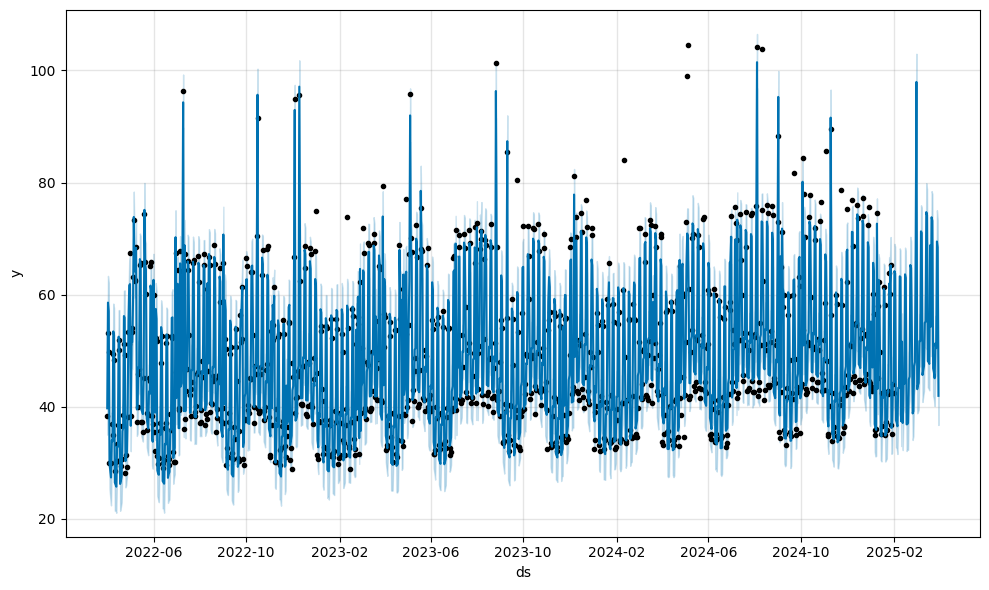

In [31]:
# ご神託をプロットします。
fig = model.plot(predict)
# 黒点が実測値で青線が予測値

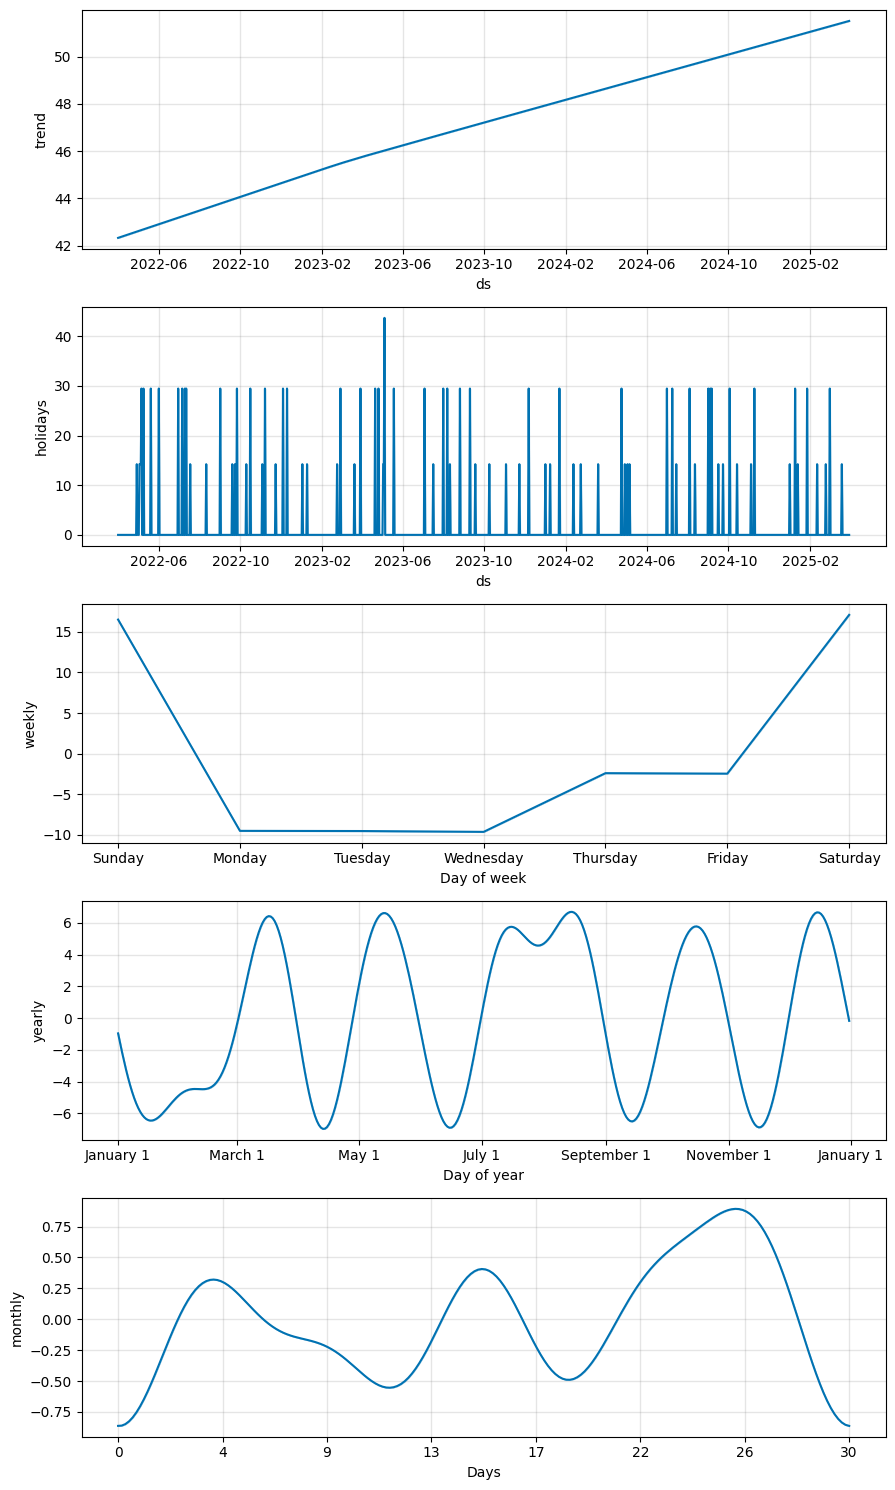

In [32]:
# 成分分解
fig = model.plot_components(predict)
# 週の周期性、観測データは平日に低く土日に高い様子などが確認できる

# check predicted

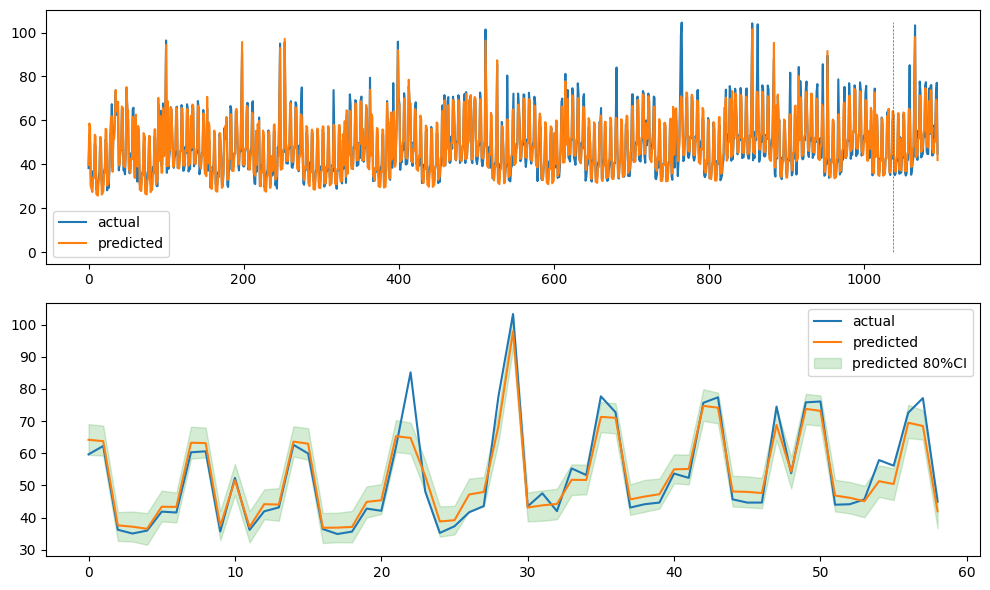

In [33]:
# 作成したモデルの予測精度を検証しますその1
plt.figure(figsize=(10,6))
# trainだけでなくtest期間の実績値含めてプロットします
plt.subplot(211) #グラフ2行1列の1番目の位置
plt.plot(df['y'], label='actual')
plt.plot(predict['yhat'], label='predicted') 
plt.vlines(x=test_date_index, ymin=0, ymax=max_lim, linestyles='--', linewidth=0.5)
plt.legend(loc='best')

# test期間だけのもプロットします
#test期間の点推定での予測値と区間推定での予測値（80%用区間）を取り出す
df_predict = pd.DataFrame(predict)
df_predict = df_predict[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].query('ds>=@test_date')
#実測値と予測値と88％CIを結合してちょい加工します
df_yhat = pd.merge(df_test[['ds', 'y']], df_predict[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

#test用に分割しておいた実測値とモデルが出力した予測値+80%credible intervalをプロット
plt.subplot(212) #グラフ2行1列の2番目の位置
plt.plot(df_yhat['y'], label="actual", color='tab:blue') # 実測値
plt.plot(df_yhat['yhat'], label="predicted", color='tab:orange')  # 点推定の予測値
plt.fill_between(df_yhat.index, df_yhat['yhat_lower'], df_yhat['yhat_upper'], color='tab:green', alpha=.2, label='predicted 80%CI')
plt.legend(loc='best')

# for setting x-axis to daily units when the test period is short.
# plt.xticks(pd.date_range(start=df_yhat.index.min(), end=df_yhat.index.max(), freq='D'))

plt.tight_layout()

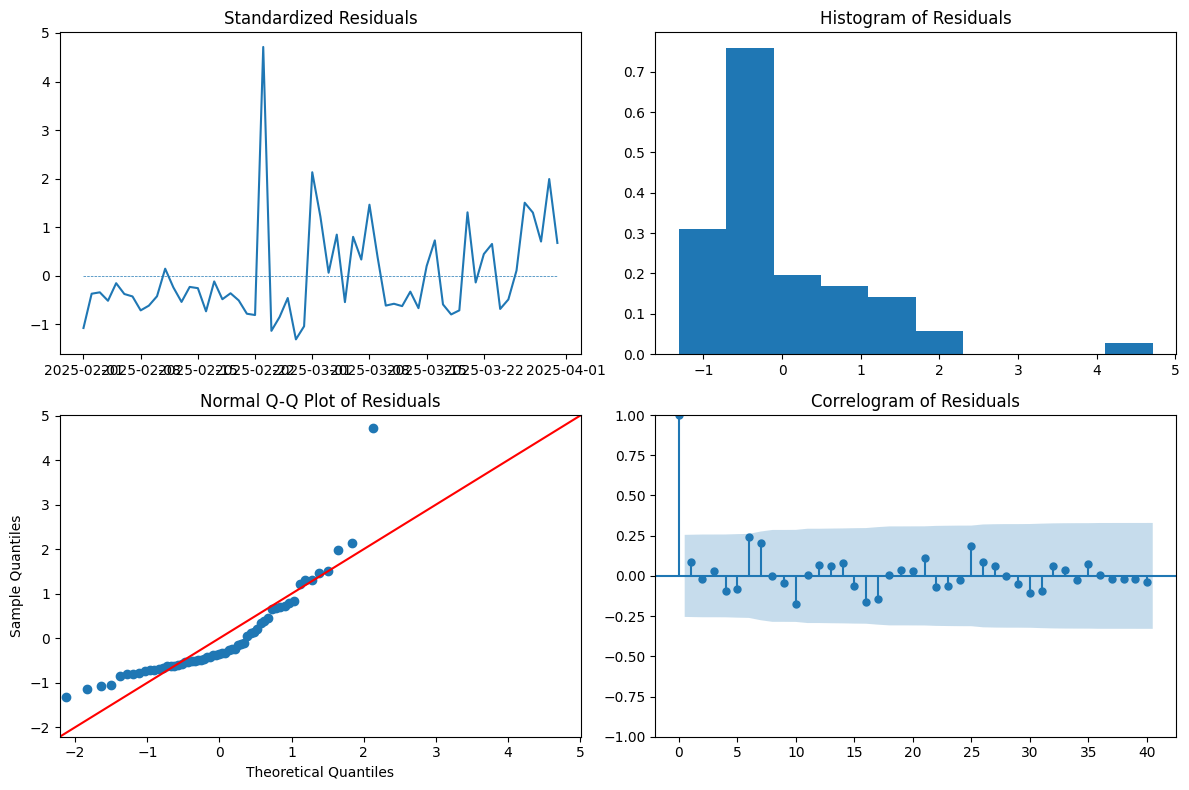

In [34]:
# 作成したモデルの予測精度を検証しますその2
# 残差が正規分布していることや自己相関の有無を確認します、もしモデルが妥当であれば、残差（説明しきれない部分）はホワイトノイズになるためです
# 残差の系列、ヒストグラム、正規Q-Qプロット、コレログラムをプロットします
from scipy.stats import zscore, norm
import statsmodels.api as sm

# 残差を計算する関数（Prophetには残差の計算機能がない）
def calculate_residuals(df, df_predict):
    df_dropna = df[['ds', 'y']].dropna().reset_index(drop=True)  # naのは除外しておかないといけない
    merged_df = pd.merge(df_dropna, df_predict[['ds', 'yhat']], on='ds').dropna()  # 観測データとpredictをmerge
    merged_df['residual'] = merged_df['y'] - merged_df['yhat']  # 残差を計算して格納
    return merged_df

df_res = calculate_residuals(df, df_predict)

# 残差を標準化
standardized_residuals = zscore(df_res['residual'])

# プロットの設定
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# fig-suptitle("Residual Analysis")

# 標準化された残差の系列
axes[0, 0].set_title("Standardized Residuals")
axes[0, 0].hlines(y=0, xmin=df_res['ds'].min(), xmax=df_res['ds'].max(), linestyles='dashed', linewidth=0.5)
axes[0, 0].plot(df_res['ds'], standardized_residuals)

# 標準化された残差のヒストグラム
axes[0, 1].set_title("Histogram of Residuals")
axes[0, 1].hist(standardized_residuals, density=True, label="Hist")
norm_x = np.linspace(standardized_residuals.min(), standardized_residuals.max(), 100)
norm_y = norm.pdf(norm_x, loc=0, scale=1)

# 残差のQ-Qプロット
axes[1, 0].set_title("Normal Q-Q Plot of Residuals")
sm.qqplot(df_res['residual'], fit=True, line='45', ax=axes[1, 0])

# 残差のコレログラム
axes[1, 1].set_title("Correlogram of Residuals")
sm.graphics.tsa.plot_acf(df_res['residual'], lags=40, ax=axes[1, 1], title="Correlogram of Residuals")
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.tight_layout()
plt.show()

In [35]:
# 作成したモデルの予測精度を検証しますその3＃実測値と予測値の誤差をMAE,MAPE, RMSE,RMSPEで評価します
import math
# MAE（平均絶対誤差）を計算する関数
def mae (true, pred):
    return np.mean(np.abs(true - pred))
# MAPE（平均絶対誤差率）を計算する関数
def mape(true, pred) :
    return np.mean(np.abs((true - pred) / true)) * 100
# RMSE（平均平方二乗誤差）を計算する関数
def rmse (true, pred):
    return math.sqrt(np.mean((true - pred) ** 2))
# RMSPEを計算する関数
def rmspe(true, pred):
    return math.sqrt(np.mean(((true - pred) / true) ** 2))

# データをNumPy配列に変換
true_values = df_yhat['y'].astype(float).to_numpy()
pred_values = df_yhat['yhat'].astype(float).to_numpy()

# 各指標を算出して表示
print('MAE: {:.3f}'.format(mae(true_values, pred_values)))
print('MAPE: {:.3f}'.format(mape(true_values, pred_values)))
print('RMSE: {:.3f}'.format(rmse(true_values, pred_values)))
print('RMSPE: {:.3f}'.format(rmspe(true_values, pred_values)))

MAE: 3.132
MAPE: 5.665
RMSE: 4.302
RMSPE: 0.068


In [36]:
df_predict.head()

,ds,yhat,yhat_lower,yhat_upper
1037,2025-02-01,64.204525,59.540234,69.073641
1038,2025-02-02,63.765752,59.246398,68.581679
1039,2025-02-03,37.610912,32.765705,41.706691
1040,2025-02-04,37.183845,32.591873,41.911869
1041,2025-02-05,36.534778,31.579023,41.409256


In [37]:
# test期間とその直前あたりだけで描画したいので、実測値と予測値と80％CIを結合してちょい加工します
df_total_yhat = pd.merge(df[['ds', 'y']], df_predict[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left')

df_total_yhat.rename(columns={'ds': 'date', 'y': 'actual', 'yhat': 'predicted', 'yhat_lower': 'predicted_lower', 'yhat_upper': 'predicted_upper'}, inplace=True)

df_total_yhat['diff'] = df_total_yhat['actual'] - df_total_yhat['predicted']
df_total_yhat['diff_lower'] = df_total_yhat['actual'] - df_total_yhat['predicted_lower']
df_total_yhat['diff_upper'] = df_total_yhat['actual'] - df_total_yhat['predicted_upper']

# 上記計算式の場合、actualとpredictedの大小関係次第では1owerとupperが逆転することがある
# そのため、大小関係をチェックして、逆転していたら入れ替えたい場合は以下コード（ことでこの値を用いたグラフ描画などはやりやすくなる）
# ただし数表で提示する場合だけ考えるとこの逆転処理は直感に反してかえってわかりにくくなる可能性あるためあんまりやらないほうがいいかも
# diff_lowerとdiff_upperの大小関係をチェックして、逆転していたら入れ替える
# for index, row in df_total_yhat.iterrows():
#     if row['diff_lower'] > row['diff_upper']:
#         # 値を入れ替える
#         df_total_yhat.at[index, 'diff_lower'], df_total_yhat.at[index, 'diff_upper'] = row['diff_upper'], row['diff_lower']

In [38]:
# print(df_total_yhat.head())
df_total_yhat.tail()

,date,actual,predicted,predicted_lower,predicted_upper,diff,diff_lower,diff_upper
1091,2025-03-27,57.890711,51.323554,46.420015,56.244084,6.567157,11.470696,1.646628
1092,2025-03-28,56.152385,50.459528,45.487821,55.302931,5.692857,10.664563,0.849454
1093,2025-03-29,72.617068,69.490720,64.759056,75.065336,3.126348,7.858012,-2.448267
1094,2025-03-30,77.146511,68.481548,64.250270,73.359657,8.664962,12.896241,3.786854
1095,2025-03-31,44.963867,41.959546,36.761908,46.509283,3.004321,8.201959,-1.545415


In [39]:
# trainのプロット期間を14daysに絞りたい
before_start_date = test_date - pd.Timedelta(days=14)
# before_start_date = pd.to_datetime("2025-01-01")

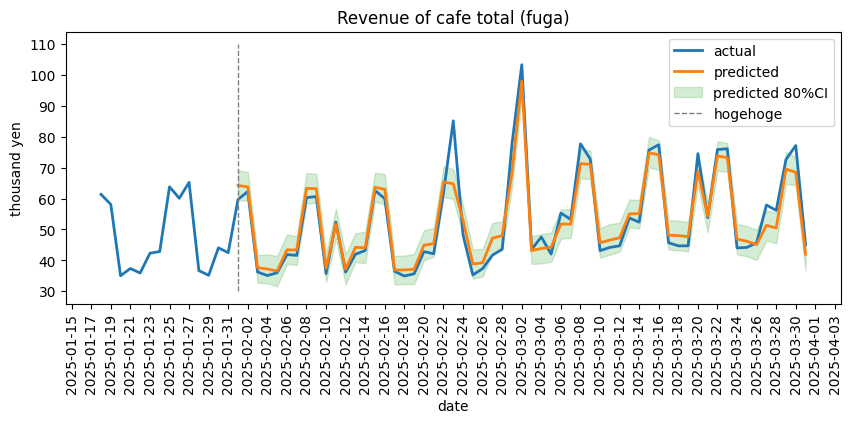

In [40]:
# before/after
plt.figure(figsize=(10, 4))
sns.lineplot(x='date', y='actual', data=df_total_yhat.query('date>=@before_start_date'), linewidth=2, label='actual')
sns.lineplot(x='date', y='predicted', data=df_total_yhat.query('date>=@before_start_date'), linewidth=2, label='predicted')
# plt.fill_between (df_yhat.index, df_yhat['yhat_lower'], df_yhat['yhat_upper'], color='tab:green', alpha=.2, label='predicted 80%CI')
plt.fill_between(df_total_yhat.query('date>=@test_date')['date'], df_total_yhat.query('date>=@test_date')['predicted_lower'], df_total_yhat.query('date >=@test_date')['predicted_upper'], color='tab:green', alpha=.2, label='predicted 80%CI')

# plot base_date
# min_lim = df_total_yhat['y'].min() - 50
min_lim = 0
max_lim = df_total_yhat['actual'].max() + 10

# plt.vlines(x=test_date, ymin=min_lim, ymax=max_lim, colors='gray', linestyles='dashed', linewidth=1, label='hogehoge')
plt.vlines(x=test_date, ymin=30, ymax=110, colors='gray', linestyles='dashed', linewidth=1, label='hogehoge')

# plt.ylim(min_lim, max_lim)
# plt.ylim(0, max_lim)
# plt.ylim(0,200)

# 横軸を日次単位に設定
import matplotlib.dates as mdates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

# 1日ごとに目盛りを設定
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d")) #日付フォーマットを設定
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d")) #日付フォーマットを設定

plt.gcf().autofmt_xdate()  # ラベルを見やすくするために自動フォーマット
plt.xticks(rotation=90, ha='center')
plt.xlabel("date")
plt.ylabel ("thousand yen")
plt. title("Revenue of cafe total (fuga)", fontsize=12)
plt.legend(loc='best')
plt.show()

# cross validation

In [41]:
from prophet.diagnostics import cross_validation
df_cv1 = cross_validation(model, initial='370 days', period='90 days', horizon = '60 days')

# 引数	意味	イメージ
# initial	最初の学習期間	最初に「これだけのデータが溜まったら検証を始めよう」という期間。今回は370日（約1年）。
# period	検証の間隔	次の検証ポイントまで、どれくらいずつずらしていくか。今回は90日（約3ヶ月）ごと。
# horizon	予測（検証）期間	各検証ポイントから、どれくらい先まで予測して精度を確かめるか。今回は60日（約2ヶ月）。

# 1回目の検証（Cutoff 1）
# 学習: 1日目〜370日目（initial）のデータを使ってモデルを作る。
# 予測: その後の60日間（horizon）を予測して、実際の売上と比較する。
# 2回目の検証（Cutoff 2）
# 学習: 1回目の開始地点から、90日（period）進めた時点までのデータを使う。
# つまり、1日目〜460日目（370 + 90）のデータで学習。
# 予測: その後の60日間（horizon）を予測して比較する。

  0%|          | 0/7 [00:00<?, ?it/s]

10:47:48 - cmdstanpy - INFO - Chain [1] start processing
10:47:48 - cmdstanpy - INFO - Chain [1] done processing
10:47:48 - cmdstanpy - INFO - Chain [1] start processing
10:47:48 - cmdstanpy - INFO - Chain [1] done processing
10:47:48 - cmdstanpy - INFO - Chain [1] start processing
10:47:48 - cmdstanpy - INFO - Chain [1] done processing
10:47:48 - cmdstanpy - INFO - Chain [1] start processing
10:47:48 - cmdstanpy - INFO - Chain [1] done processing
10:47:48 - cmdstanpy - INFO - Chain [1] start processing
10:47:48 - cmdstanpy - INFO - Chain [1] done processing
10:47:48 - cmdstanpy - INFO - Chain [1] start processing
10:47:48 - cmdstanpy - INFO - Chain [1] done processing
10:47:48 - cmdstanpy - INFO - Chain [1] start processing
10:47:48 - cmdstanpy - INFO - Chain [1] done processing


In [42]:
from prophet.diagnostics import performance_metrics
df_p1 = performance_metrics(df_cv1)
df_p1.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,6 days,5.691637,2.385715,1.920297,0.041794,0.032780,0.041862,0.928571
1,7 days,6.132165,2.476321,2.003504,0.043069,0.033830,0.043010,0.928571
2,8 days,5.523998,2.350319,1.943457,0.042127,0.035942,0.041864,0.952381
3,9 days,5.540397,2.353805,1.976886,0.042950,0.037430,0.042669,0.952381
4,10 days,4.828394,2.197361,1.795356,0.038609,0.034866,0.038370,0.952381


/opt/homebrew/Caskroom/miniforge/base/envs/ci_env/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/opt/homebrew/Caskroom/miniforge/base/envs/ci_env/lib/python3.11/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


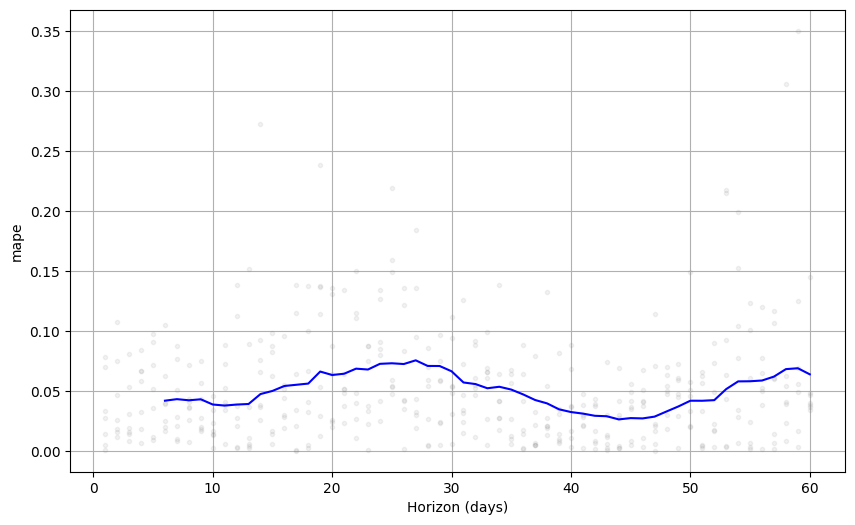

In [43]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv1, metric='mape')

In [44]:
# 期間を自動で計算させるのではなく、この日付を基準（カットオフ）にして検証してほしい場合に使う方法
# cutoffsを指定する意味: initialやperiodで機械的に分割せず、cutoffsを使うと「特定のイベントの直前」などを指定して検証できる

# 以下設定だと、以下の3つのステップで検証がおこなわれる
# 1回目の検証（基準日：2023-05-15）
# 学習: 2023-05-15 以前のデータを使って学習。
# 予測: その日から 60日間 (horizon) 先を予測して、実績と比較。
cutoffs = pd.to_datetime(['2023-05-15', '2024-02-10', '2024-10-20'])
df_cv2 = cross_validation(model, cutoffs=cutoffs, horizon='60 days')

  0%|          | 0/3 [00:00<?, ?it/s]

10:47:49 - cmdstanpy - INFO - Chain [1] start processing
10:47:49 - cmdstanpy - INFO - Chain [1] done processing
10:47:49 - cmdstanpy - INFO - Chain [1] start processing
10:47:49 - cmdstanpy - INFO - Chain [1] done processing
10:47:49 - cmdstanpy - INFO - Chain [1] start processing
10:47:49 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
from prophet.diagnostics import performance_metrics
df_p2 = performance_metrics(df_cv2)
df_p2.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,6 days,40.384587,6.354887,2.821870,0.045548,0.015797,0.047973,0.888889
1,7 days,7.239609,2.690652,1.755000,0.030725,0.015797,0.030622,0.888889
2,8 days,7.329684,2.707339,1.777087,0.030225,0.015797,0.030173,0.888889
3,9 days,7.723441,2.779108,1.910657,0.033814,0.018047,0.034109,0.888889
4,10 days,8.105667,2.847045,2.041046,0.037991,0.027128,0.038552,0.888889


/opt/homebrew/Caskroom/miniforge/base/envs/ci_env/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/opt/homebrew/Caskroom/miniforge/base/envs/ci_env/lib/python3.11/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


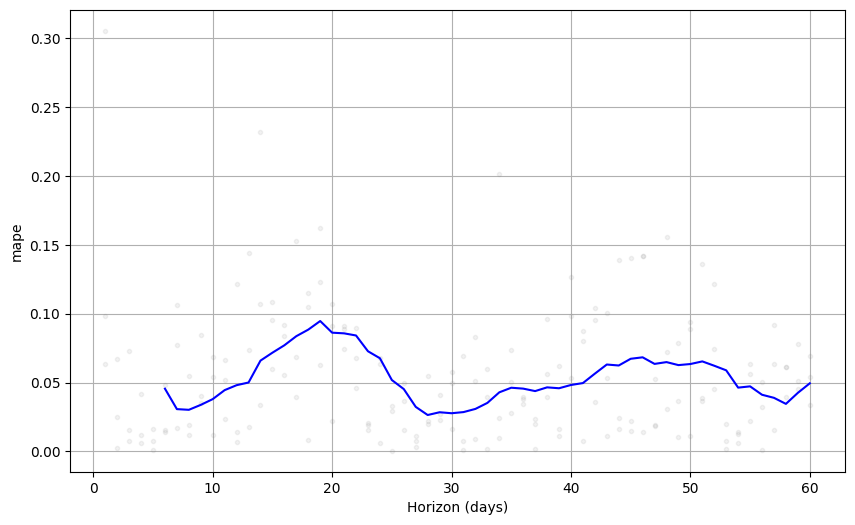

In [46]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv2, metric='mape')